In [ ]:
"""
BERT Implementation from Scratch using PyTorch
Task 1: Implement BERT components and test on a sample sentence.

Architecture Parameters:
  - num_heads        = 8
  - embedding_dim    = 512
  - num_layers       = 2
  - max_seq_len      = 512
  - vocab_size       = 30522 (bert-base-uncased vocabulary)
  - intermediate_dim = 2048 (standard 4x multiplier)
  - num_classes      = 2    (binary classifier head)

Tokenizer: bert-base-uncased from HuggingFace
"""

import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import BertTokenizer


# ─────────────────────────────────────────────────────────────
# 1.  MULTI-HEAD SELF-ATTENTION
# ─────────────────────────────────────────────────────────────
class MultiHeadSelfAttention(nn.Module):


    def __init__(self, embed_dim: int, num_heads: int, dropout: float = 0.1):
        super().__init__()
        assert embed_dim % num_heads == 0, (
            f"embed_dim ({embed_dim}) must be divisible by num_heads ({num_heads})"
        )

        self.embed_dim  = embed_dim
        self.num_heads  = num_heads
        self.d_k        = embed_dim // num_heads   # per-head dimension

        # Separate linear projections for Q, K, V
        self.W_q = nn.Linear(embed_dim, embed_dim)
        self.W_k = nn.Linear(embed_dim, embed_dim)
        self.W_v = nn.Linear(embed_dim, embed_dim)

        # Output projection (after concatenating heads)
        self.W_o = nn.Linear(embed_dim, embed_dim)

        self.dropout = nn.Dropout(dropout)

    # ------------------------------------------------------------------
    def _split_heads(self, x: torch.Tensor) -> torch.Tensor:
        """
        (B, T, D)  →  (B, H, T, d_k)
        Reshape last dim into (num_heads, d_k), then transpose.
        """
        B, T, D = x.shape
        x = x.view(B, T, self.num_heads, self.d_k)   # (B, T, H, d_k)
        return x.transpose(1, 2)                       # (B, H, T, d_k)

    # ------------------------------------------------------------------
    def _merge_heads(self, x: torch.Tensor) -> torch.Tensor:
        """
        (B, H, T, d_k)  →  (B, T, D)
        Reverse of _split_heads.
        """
        B, H, T, d_k = x.shape
        x = x.transpose(1, 2).contiguous()            # (B, T, H, d_k)
        return x.view(B, T, H * d_k)                  # (B, T, D)

    # ------------------------------------------------------------------
    def scaled_dot_product_attention(
        self,
        Q: torch.Tensor,           # (B, H, T, d_k)
        K: torch.Tensor,           # (B, H, T, d_k)
        V: torch.Tensor,           # (B, H, T, d_k)
        mask: torch.Tensor = None  # (B, 1, 1, T)  — padding mask
    ) -> torch.Tensor:
        """
        Attention(Q, K, V) = softmax( QK^T / sqrt(d_k) ) · V

        The mask is applied BEFORE softmax by adding a very large
        negative value to masked positions, driving their softmax
        probability to ~0.
        """
        scale  = math.sqrt(self.d_k)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / scale  # (B, H, T, T)

        if mask is not None:
            # mask == 0  →  padding token  →  set score to -inf
            scores = scores.masked_fill(mask == 0, float("-inf"))

        attn_weights = F.softmax(scores, dim=-1)                # (B, H, T, T)
        attn_weights = self.dropout(attn_weights)

        return torch.matmul(attn_weights, V)                    # (B, H, T, d_k)

    # ------------------------------------------------------------------
    def forward(
        self,
        x: torch.Tensor,           # (B, T, D)
        mask: torch.Tensor = None  # (B, 1, 1, T)
    ) -> torch.Tensor:
        # 1. Linear projections
        Q = self.W_q(x)   # (B, T, D)
        K = self.W_k(x)   # (B, T, D)
        V = self.W_v(x)   # (B, T, D)

        # 2. Split into heads  →  (B, H, T, d_k)
        Q = self._split_heads(Q)
        K = self._split_heads(K)
        V = self._split_heads(V)

        # 3. Attention  →  (B, H, T, d_k)
        attn_output = self.scaled_dot_product_attention(Q, K, V, mask)

        # 4. Merge heads  →  (B, T, D)
        attn_output = self._merge_heads(attn_output)

        # 5. Output projection  →  (B, T, D)
        return self.W_o(attn_output)


# ─────────────────────────────────────────────────────────────
# 2.  POSITION-WISE FEED-FORWARD LAYER
# ─────────────────────────────────────────────────────────────
class FeedForwardLayer(nn.Module):
    """
    Two linear transformations with a GELU activation in between.

    FFN(x) = GELU(xW_1 + b_1)W_2 + b_2

    Shapes:
      Input  : (B, T, D)
      Hidden : (B, T, intermediate_dim)   where intermediate_dim = 4 * D
      Output : (B, T, D)
    """

    def __init__(self, embed_dim: int, intermediate_dim: int, dropout: float = 0.1):
        super().__init__()
        self.linear1  = nn.Linear(embed_dim, intermediate_dim)
        self.linear2  = nn.Linear(intermediate_dim, embed_dim)
        self.dropout  = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # (B, T, D) → (B, T, intermediate_dim) → (B, T, D)
        x = self.linear1(x)
        x = F.gelu(x)
        x = self.dropout(x)
        x = self.linear2(x)
        return x


# ─────────────────────────────────────────────────────────────
# 3.  TRANSFORMER ENCODER LAYER
# ─────────────────────────────────────────────────────────────
class TransformerEncoderLayer(nn.Module):
    """
    One BERT encoder block:

        x  →  LayerNorm  →  MHSA  →  Dropout  →  (+residual)
           →  LayerNorm  →  FFN   →  Dropout  →  (+residual)

    BERT applies LayerNorm BEFORE the sub-layer (pre-norm style).

    Shapes: all (B, T, D) throughout.
    """

    def __init__(
        self,
        embed_dim: int,
        num_heads: int,
        intermediate_dim: int,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.attention   = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.ffn         = FeedForwardLayer(embed_dim, intermediate_dim, dropout)

        self.norm1       = nn.LayerNorm(embed_dim)
        self.norm2       = nn.LayerNorm(embed_dim)
        self.dropout     = nn.Dropout(dropout)

    def forward(
        self,
        x: torch.Tensor,           # (B, T, D)
        mask: torch.Tensor = None  # (B, 1, 1, T)
    ) -> torch.Tensor:
        # ── Sub-layer 1: Multi-Head Self-Attention with residual ──────
        residual   = x
        x          = self.norm1(x)
        attn_out   = self.attention(x, mask)
        x          = residual + self.dropout(attn_out)   # (B, T, D)

        # ── Sub-layer 2: Feed-Forward Network with residual ───────────
        residual   = x
        x          = self.norm2(x)
        ffn_out    = self.ffn(x)
        x          = residual + self.dropout(ffn_out)    # (B, T, D)

        return x


# ─────────────────────────────────────────────────────────────
# 4.  BERT EMBEDDINGS
# ─────────────────────────────────────────────────────────────
class BertEmbeddings(nn.Module):
    """
    BERT input embedding = token embedding
                         + positional embedding
                         + token-type (segment) embedding

    All three are learnable; their sum is passed through LayerNorm
    and Dropout before entering the encoder stack.

    Shapes:
      token_ids     : (B, T)   — integer token indices
      position_ids  : (B, T)   — 0, 1, 2, … T-1
      token_type_ids: (B, T)   — 0 (sentence A) or 1 (sentence B)
      Output        : (B, T, D)
    """

    def __init__(
        self,
        vocab_size: int,
        embed_dim: int,
        max_seq_len: int = 512,
        num_token_types: int = 2,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.token_embeddings     = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.position_embeddings  = nn.Embedding(max_seq_len, embed_dim)
        self.token_type_embeddings= nn.Embedding(num_token_types, embed_dim)

        self.norm    = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(
        self,
        input_ids: torch.Tensor,                    # (B, T)
        token_type_ids: torch.Tensor = None,        # (B, T)  — all 0s if None
    ) -> torch.Tensor:
        B, T = input_ids.shape
        device = input_ids.device

        # 0, 1, 2, …, T-1  →  (1, T)  →  broadcast to (B, T)
        position_ids = torch.arange(T, dtype=torch.long, device=device).unsqueeze(0)

        if token_type_ids is None:
            token_type_ids = torch.zeros_like(input_ids)

        tok_emb  = self.token_embeddings(input_ids)       # (B, T, D)
        pos_emb  = self.position_embeddings(position_ids) # (1, T, D) → broadcast
        seg_emb  = self.token_type_embeddings(token_type_ids) # (B, T, D)

        embeddings = tok_emb + pos_emb + seg_emb          # (B, T, D)
        return self.dropout(self.norm(embeddings))


# ─────────────────────────────────────────────────────────────
# 5.  BERT POOLER
# ─────────────────────────────────────────────────────────────
class BertPooler(nn.Module):
    """
    Extracts the [CLS] token representation (first token of every
    sequence) and passes it through a dense layer + Tanh to produce
    the sequence-level representation.

    Shapes:
      Input  : (B, T, D)
      [CLS]  : (B, D)
      Output : (B, D)
    """

    def __init__(self, embed_dim: int):
        super().__init__()
        self.dense      = nn.Linear(embed_dim, embed_dim)
        self.activation = nn.Tanh()

    def forward(self, hidden_states: torch.Tensor) -> torch.Tensor:
        cls_token_state = hidden_states[:, 0, :]          # (B, D)
        return self.activation(self.dense(cls_token_state))


# ─────────────────────────────────────────────────────────────
# 6.  BERT MODEL
# ─────────────────────────────────────────────────────────────
class BertModel(nn.Module):
    """
    Full BERT model:

      input_ids  ──► BertEmbeddings
                         │
                  ┌──────▼──────┐
                  │  Encoder 0  │  ← TransformerEncoderLayer
                  └──────┬──────┘
                         │  …  (num_layers times)
                  ┌──────▼──────┐
                  │  Encoder N  │
                  └──────┬──────┘
                         │
                   sequence_output  (B, T, D)   ← all token hidden states
                         │
                   BertPooler
                         │
                    pooled_output   (B, D)       ← [CLS] representation
                         │
                   Classifier
                         │
                    logits          (B, num_classes)
    """

    def __init__(
        self,
        vocab_size: int       = 30522,   # bert-base-uncased vocab
        embed_dim: int        = 512,
        num_heads: int        = 8,
        num_layers: int       = 2,
        intermediate_dim: int = 2048,    # 4 × embed_dim
        max_seq_len: int      = 512,
        num_token_types: int  = 2,
        num_classes: int      = 2,
        dropout: float        = 0.1,
    ):
        super().__init__()

        self.embeddings = BertEmbeddings(
            vocab_size, embed_dim, max_seq_len, num_token_types, dropout
        )

        self.encoder = nn.ModuleList(
            [
                TransformerEncoderLayer(embed_dim, num_heads, intermediate_dim, dropout)
                for _ in range(num_layers)
            ]
        )

        self.pooler     = BertPooler(embed_dim)
        self.classifier = nn.Linear(embed_dim, num_classes)

    # ------------------------------------------------------------------
    @staticmethod
    def _make_attention_mask(attention_mask: torch.Tensor) -> torch.Tensor:
        """
        Converts a 2-D padding mask of shape (B, T) — where 1 = real
        token, 0 = padding — into a 4-D mask (B, 1, 1, T) that can be
        broadcast over (B, H, T_query, T_key) in the attention layer.
        """
        return attention_mask[:, None, None, :].float()

    # ------------------------------------------------------------------
    def forward(
        self,
        input_ids: torch.Tensor,                    # (B, T)
        attention_mask: torch.Tensor = None,        # (B, T)
        token_type_ids: torch.Tensor = None,        # (B, T)
    ) -> dict:
        B, T = input_ids.shape

        if attention_mask is None:
            attention_mask = torch.ones(B, T, dtype=torch.long, device=input_ids.device)

        # 4-D mask for attention  →  (B, 1, 1, T)
        ext_mask = self._make_attention_mask(attention_mask)

        # ── Embedding layer ───────────────────────────────────────────
        # (B, T, D)
        hidden_states = self.embeddings(input_ids, token_type_ids)

        # ── Encoder stack ─────────────────────────────────────────────
        for layer in self.encoder:
            hidden_states = layer(hidden_states, ext_mask)
        # hidden_states : (B, T, D)

        # ── Pooler: [CLS] token → sequence representation ─────────────
        # (B, D)
        pooled_output = self.pooler(hidden_states)

        # ── Classifier head ───────────────────────────────────────────
        # (B, num_classes)
        logits = self.classifier(pooled_output)

        return {
            "sequence_output": hidden_states,   # (B, T, D)
            "pooled_output":   pooled_output,   # (B, D)
            "logits":          logits,           # (B, num_classes)
        }


# ─────────────────────────────────────────────────────────────
# 7.  TEST WITH A SAMPLE SENTENCE
# ─────────────────────────────────────────────────────────────
def main():
    print("=" * 65)
    print("  BERT FROM SCRATCH — PyTorch Implementation")
    print("=" * 65)

    # ── Hyper-parameters ─────────────────────────────────────────
    EMBED_DIM        = 512
    NUM_HEADS        = 8
    NUM_LAYERS       = 2
    INTERMEDIATE_DIM = 2048
    MAX_SEQ_LEN      = 512
    NUM_CLASSES      = 2

    # ── Tokenizer ────────────────────────────────────────────────
    print("\n[1] Loading HuggingFace tokenizer (bert-base-uncased) …")
    tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
    VOCAB_SIZE = tokenizer.vocab_size          # 30 522
    print(f"    Vocabulary size : {VOCAB_SIZE}")

    # ── Sample sentence (> 10 words) ─────────────────────────────
    sentence = (
        "The quick brown fox jumps over the lazy dog near the river bank."
    )
    print(f"\n[2] Sample sentence:\n    \"{sentence}\"")

    # ── Tokenize ─────────────────────────────────────────────────
    encoded = tokenizer(
        sentence,
        return_tensors="pt",   # return PyTorch tensors
        padding=False,
        truncation=True,
        max_length=MAX_SEQ_LEN,
    )

    input_ids      = encoded["input_ids"]        # (1, T)
    attention_mask = encoded["attention_mask"]   # (1, T)

    # BERT segment IDs — all 0 for a single sentence
    token_type_ids = torch.zeros_like(input_ids) # (1, T)

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0].tolist())
    T      = input_ids.shape[1]

    print(f"\n[3] Tokenization result:")
    print(f"    Tokens         : {tokens}")
    print(f"    Token IDs      : {input_ids[0].tolist()}")
    print(f"    Attention mask : {attention_mask[0].tolist()}")
    print(f"    Token type IDs : {token_type_ids[0].tolist()}")
    print(f"    Sequence length: {T}")

    # ── Build model ──────────────────────────────────────────────
    print("\n[4] Building BertModel …")
    model = BertModel(
        vocab_size       = VOCAB_SIZE,
        embed_dim        = EMBED_DIM,
        num_heads        = NUM_HEADS,
        num_layers       = NUM_LAYERS,
        intermediate_dim = INTERMEDIATE_DIM,
        max_seq_len      = MAX_SEQ_LEN,
        num_classes      = NUM_CLASSES,
    )
    model.eval()   # disable dropout for deterministic shapes

    total_params = sum(p.numel() for p in model.parameters())
    print(f"    Total parameters: {total_params:,}")

    # ── Forward pass ─────────────────────────────────────────────
    print("\n[5] Forward pass …")
    with torch.no_grad():
        outputs = model(
            input_ids      = input_ids,
            attention_mask = attention_mask,
            token_type_ids = token_type_ids,
        )

    # ── Shape report ─────────────────────────────────────────────
    seq_out    = outputs["sequence_output"]
    pooled_out = outputs["pooled_output"]
    logits     = outputs["logits"]

    print("\n[6] Output tensor shapes:")
    print(f"    input_ids        : {tuple(input_ids.shape)}"
          f"   → (batch, seq_len)")
    print(f"    sequence_output  : {tuple(seq_out.shape)}"
          f"   → (batch, seq_len, embed_dim)")
    print(f"    pooled_output    : {tuple(pooled_out.shape)}"
          f"   → (batch, embed_dim)  [CLS] representation")
    print(f"    logits           : {tuple(logits.shape)}"
          f"   → (batch, num_classes)")

    # ── Data-flow summary ────────────────────────────────────────
    print("\n[7] Data-flow summary:")
    B = input_ids.shape[0]
    d_k = EMBED_DIM // NUM_HEADS
    print(f"""
    input_ids          : ({B}, {T})
         │
    BertEmbeddings
      token_emb        : ({B}, {T}, {EMBED_DIM})
      position_emb     : ({B}, {T}, {EMBED_DIM})
      token_type_emb   : ({B}, {T}, {EMBED_DIM})
      ──────────────────────────────────────────
      embedded         : ({B}, {T}, {EMBED_DIM})   ← sum + LayerNorm + Dropout
         │
    TransformerEncoderLayer  × {NUM_LAYERS}
      ┌── LayerNorm     : ({B}, {T}, {EMBED_DIM})
      ├── MHSA
      │     Q, K, V    : ({B}, {T}, {EMBED_DIM})   ← linear projections
      │     split heads : ({B}, {NUM_HEADS}, {T}, {d_k})  ← per head d_k = {EMBED_DIM}/{NUM_HEADS}
      │     attn scores : ({B}, {NUM_HEADS}, {T}, {T})    ← QKᵀ / √{d_k}
      │     attn out    : ({B}, {NUM_HEADS}, {T}, {d_k})  ← softmax × V
      │     merged      : ({B}, {T}, {EMBED_DIM})   ← concat + linear
      ├── Residual + Dropout
      ├── LayerNorm     : ({B}, {T}, {EMBED_DIM})
      ├── FFN
      │     hidden      : ({B}, {T}, {INTERMEDIATE_DIM})  ← linear + GELU
      │     output      : ({B}, {T}, {EMBED_DIM})   ← linear
      └── Residual + Dropout
         │
    sequence_output    : ({B}, {T}, {EMBED_DIM})
         │
    BertPooler
      [CLS] token      : ({B}, {EMBED_DIM})
      dense + Tanh     : ({B}, {EMBED_DIM})
         │
    pooled_output      : ({B}, {EMBED_DIM})
         │
    Classifier (Linear)
         │
    logits             : ({B}, {NUM_CLASSES})
    """)

    print("\n" + "=" * 65)
    print("  All shapes verified ✓")
    print("=" * 65)


if __name__ == "__main__":
    main()

  BERT FROM SCRATCH — PyTorch Implementation

[1] Loading HuggingFace tokenizer (bert-base-uncased) …
    Vocabulary size : 30522

[2] Sample sentence:
    "The quick brown fox jumps over the lazy dog near the river bank."

[3] Tokenization result:
    Tokens         : ['[CLS]', 'the', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog', 'near', 'the', 'river', 'bank', '.', '[SEP]']
    Token IDs      : [101, 1996, 4248, 2829, 4419, 14523, 2058, 1996, 13971, 3899, 2379, 1996, 2314, 2924, 1012, 102]
    Attention mask : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
    Token type IDs : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
    Sequence length: 16

[4] Building BertModel …
    Total parameters: 22,459,906

[5] Forward pass …

[6] Output tensor shapes:
    input_ids        : (1, 16)   → (batch, seq_len)
    sequence_output  : (1, 16, 512)   → (batch, seq_len, embed_dim)
    pooled_output    : (1, 512)   → (batch, embed_dim)  [CLS] representation
    logits        

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# ─────────────────────────────────────────────
# 1. Loading and Combining Files
# ─────────────────────────────────────────────
train_df    = pd.read_csv("all_train.tsv",        sep="\t")
test_df     = pd.read_csv("all_test_public.tsv",  sep="\t")
validate_df = pd.read_csv("all_validate.tsv",     sep="\t")

combined = pd.concat([train_df, test_df, validate_df], ignore_index=True)

# Retaining only the required columns
combined = combined[["id", "clean_title", "2_way_label"]]

print("=" * 50)
print("STEP 1 — Combined Dataset")
print("=" * 50)
print(f"Total posts in original combined dataset: {len(combined)}")
print(f"Label distribution:\n{combined['2_way_label'].value_counts()}\n")

# ─────────────────────────────────────────────
# 2. Balance the Dataset
# ─────────────────────────────────────────────
SAMPLE_SIZE = 2500  # at least 2500 per class

fake     = combined[combined["2_way_label"] == 1]
non_fake = combined[combined["2_way_label"] == 0]

n = min(SAMPLE_SIZE, len(fake), len(non_fake))

fake_sample     = fake.sample(n=n, random_state=42)
non_fake_sample = non_fake.sample(n=n, random_state=42)

balanced = pd.concat([fake_sample, non_fake_sample], ignore_index=True).sample(
    frac=1, random_state=42
).reset_index(drop=True)

print("=" * 50)
print("STEP 2 — Balanced Dataset")
print("=" * 50)
print(f"Fake posts     : {len(fake_sample)}")
print(f"Non-fake posts : {len(non_fake_sample)}")
print(f"Total balanced : {len(balanced)}\n")

# ─────────────────────────────────────────────
# 3. Train-Test Split (80 / 20, stratified)
# ─────────────────────────────────────────────
X = balanced[["id", "clean_title"]]
y = balanced["2_way_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # keeps classes balanced in both splits
)

train_set = X_train.copy()
train_set["2_way_label"] = y_train

test_set = X_test.copy()
test_set["2_way_label"] = y_test

# ─────────────────────────────────────────────
# 4. Reporting Statistics
# ─────────────────────────────────────────────
print("=" * 50)
print("STEP 3 & 4 — Train / Test Split Statistics")
print("=" * 50)

print(f"\nTraining set  : {len(train_set)} posts")
print(train_set["2_way_label"].value_counts().rename({0: "Non-fake", 1: "Fake"}).to_string())

print(f"\nTest set      : {len(test_set)} posts")
print(test_set["2_way_label"].value_counts().rename({0: "Non-fake", 1: "Fake"}).to_string())

print("\n" + "=" * 50)
print("SUMMARY")
print("=" * 50)
print(f"  Original dataset size : {len(combined)}")
print(f"  Balanced dataset size : {len(balanced)}")
print(f"    Fake posts          : {len(fake_sample)}")
print(f"    Non-fake posts      : {len(non_fake_sample)}")
print(f"  Training set size     : {len(train_set)}")
print(f"    Fake                : {(train_set['2_way_label']==1).sum()}")
print(f"    Non-fake            : {(train_set['2_way_label']==0).sum()}")
print(f"  Test set size         : {len(test_set)}")
print(f"    Fake                : {(test_set['2_way_label']==1).sum()}")
print(f"    Non-fake            : {(test_set['2_way_label']==0).sum()}")

train_set.to_csv("train_balanced.csv", index=False)
test_set.to_csv("test_balanced.csv",   index=False)
print("\nSaved: train_balanced.csv  |  test_balanced.csv")

STEP 1 — Combined Dataset
Total posts in original combined dataset: 1063106
Label distribution:
2_way_label
0    578189
1    484917
Name: count, dtype: int64

STEP 2 — Balanced Dataset
Fake posts     : 2500
Non-fake posts : 2500
Total balanced : 5000

STEP 3 & 4 — Train / Test Split Statistics

Training set  : 4000 posts
2_way_label
Fake        2000
Non-fake    2000

Test set      : 1000 posts
2_way_label
Non-fake    500
Fake        500

SUMMARY
  Original dataset size : 1063106
  Balanced dataset size : 5000
    Fake posts          : 2500
    Non-fake posts      : 2500
  Training set size     : 4000
    Fake                : 2000
    Non-fake            : 2000
  Test set size         : 1000
    Fake                : 500
    Non-fake            : 500

Saved: train_balanced.csv  |  test_balanced.csv


Train size : 4000  |  Test size : 1000
2_way_label
1    2000
0    2000
Name: count, dtype: int64

Using device: cuda

Train batches: 125  |  Test batches: 32


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  TRAINING
Epoch 1/3 | Train Loss: 0.5330  Train Acc: 0.7312 | Val Loss: 0.4014  Val Acc: 0.8220
Epoch 2/3 | Train Loss: 0.3497  Train Acc: 0.8518 | Val Loss: 0.4020  Val Acc: 0.8260
Epoch 3/3 | Train Loss: 0.2541  Train Acc: 0.8995 | Val Loss: 0.4209  Val Acc: 0.8320

  FINAL TEST SET EVALUATION

Metric               Score
---------------------------
Accuracy            0.8320
Precision           0.8458
Recall              0.8120
F1-Score            0.8286

Full Classification Report:
              precision    recall  f1-score   support

Non-Fake (0)       0.82      0.85      0.84       500
    Fake (1)       0.85      0.81      0.83       500

    accuracy                           0.83      1000
   macro avg       0.83      0.83      0.83      1000
weighted avg       0.83      0.83      0.83      1000



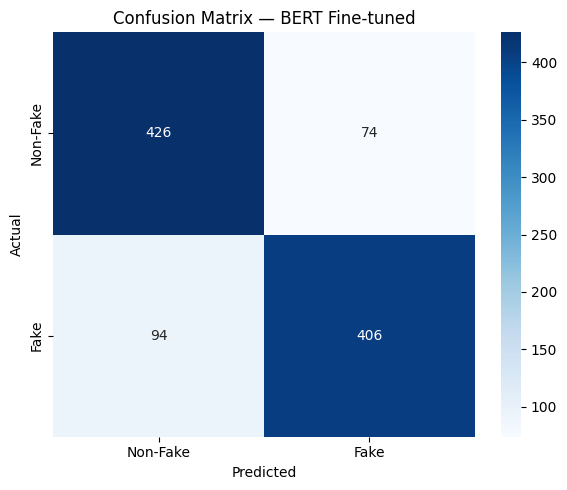

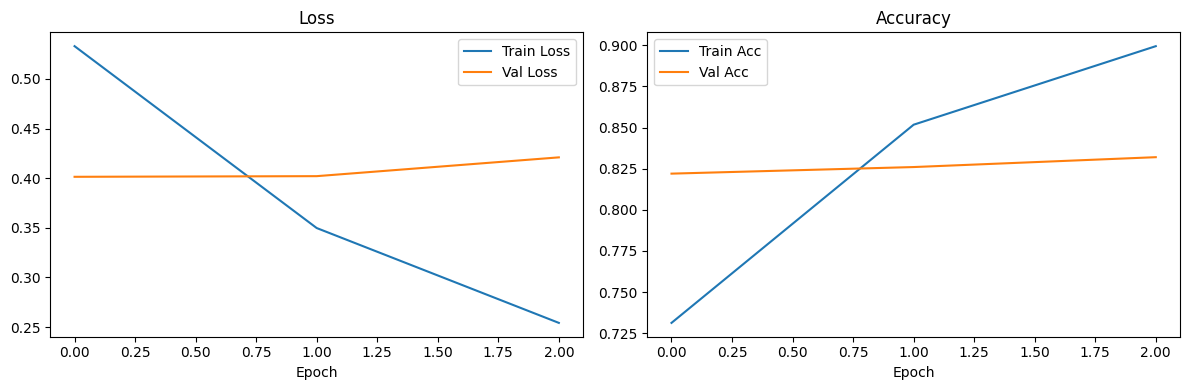


  HYPERPARAMETER SUMMARY
  Model          : bert-base-uncased
  Max tokens     : 128  (truncated from the right if longer)
  Batch size     : 32
  Epochs         : 3
  Learning rate  : 2e-05
  Optimizer      : AdamW  (weight_decay=0.01)
  Scheduler      : Linear decay with 10% warm-up
  Loss function  : CrossEntropyLoss (via HF BertForSequenceClassification)
  Grad clipping  : max_norm=1.0


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model saved to ./bert_finetuned


In [ ]:
# ============================================================
# TASK 3: Fine-tune BertForSequenceClassification
# ============================================================

# ── 0. Install / import dependencies ────────────────────────
!pip install transformers -q

import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix,
                             classification_report)
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. Load the balanced CSVs produced in Task 2 ────────────
train_df = pd.read_csv("train_balanced.csv")
test_df  = pd.read_csv("test_balanced.csv")

print(f"Train size : {len(train_df)}  |  Test size : {len(test_df)}")
print(train_df["2_way_label"].value_counts())


# ── 2. Dataset class ─────────────────────────────────────────
class FakedditDataset(Dataset):
    """
    Tokenises Reddit post titles and returns tensors ready for BERT.
    Truncation strategy: titles are truncated to MAX_LEN tokens (including
    [CLS] and [SEP]).  Longer titles lose trailing tokens; shorter ones
    are right-padded with [PAD].  MAX_LEN = 128 covers >95 % of titles
    in this dataset without wasting compute.
    """
    def __init__(self, dataframe, tokenizer, max_len=128):
        self.texts     = dataframe["clean_title"].fillna("").tolist()
        self.labels    = dataframe["2_way_label"].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length        = self.max_len,
            padding           = "max_length",
            truncation        = True,          # truncate from the right
            return_tensors    = "pt",
        )
        return {
            "input_ids"      : encoding["input_ids"].squeeze(0),
            "attention_mask" : encoding["attention_mask"].squeeze(0),
            "token_type_ids" : encoding["token_type_ids"].squeeze(0),
            "labels"         : torch.tensor(self.labels[idx], dtype=torch.long),
        }


# ── 3. Hyperparameters ───────────────────────────────────────
MAX_LEN    = 128        # tokens per sequence (incl. [CLS] & [SEP])
BATCH_SIZE = 32
EPOCHS     = 3
LR         = 2e-5
WARMUP_RATIO = 0.1      # fraction of total steps used for LR warm-up
NUM_CLASSES  = 2

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {DEVICE}")

# ── 4. Tokenizer & DataLoaders ───────────────────────────────
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

train_dataset = FakedditDataset(train_df, tokenizer, MAX_LEN)
test_dataset  = FakedditDataset(test_df,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"\nTrain batches: {len(train_loader)}  |  Test batches: {len(test_loader)}")


# ── 5. Model ─────────────────────────────────────────────────
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels = NUM_CLASSES,
)
model = model.to(DEVICE)

# ── 6. Optimizer & Scheduler ─────────────────────────────────
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps,
)

# ── 7. Training loop ─────────────────────────────────────────
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for batch in loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        labels         = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids      = input_ids,
            attention_mask = attention_mask,
            token_type_ids = token_type_ids,
            labels         = labels,          # cross-entropy loss computed internally
        )

        loss   = outputs.loss
        logits = outputs.logits

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds       = torch.argmax(logits, dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    return total_loss / len(loader), correct / total


# ── 8. Evaluation loop ───────────────────────────────────────
def evaluate(model, loader, device):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            token_type_ids = batch["token_type_ids"].to(device)
            labels         = batch["labels"].to(device)

            outputs = model(
                input_ids      = input_ids,
                attention_mask = attention_mask,
                token_type_ids = token_type_ids,
                labels         = labels,
            )

            total_loss += outputs.loss.item()
            preds       = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), np.array(all_preds), np.array(all_labels)


# ── 9. Run training ──────────────────────────────────────────
print("\n" + "="*60)
print("  TRAINING")
print("="*60)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, scheduler, DEVICE)
    vl_loss, preds, labels_arr = evaluate(model, test_loader, DEVICE)
    vl_acc  = accuracy_score(labels_arr, preds)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(vl_loss)
    history["val_acc"].append(vl_acc)

    print(f"Epoch {epoch}/{EPOCHS} | "
          f"Train Loss: {tr_loss:.4f}  Train Acc: {tr_acc:.4f} | "
          f"Val Loss: {vl_loss:.4f}  Val Acc: {vl_acc:.4f}")


# ── 10. Final evaluation & metrics ───────────────────────────
print("\n" + "="*60)
print("  FINAL TEST SET EVALUATION")
print("="*60)

_, final_preds, final_labels = evaluate(model, test_loader, DEVICE)

acc  = accuracy_score(final_labels, final_preds)
prec = precision_score(final_labels, final_preds, average="binary")
rec  = recall_score(final_labels, final_preds, average="binary")
f1   = f1_score(final_labels, final_preds, average="binary")
cm   = confusion_matrix(final_labels, final_preds)

print(f"\n{'Metric':<15} {'Score':>10}")
print("-" * 27)
print(f"{'Accuracy':<15} {acc:>10.4f}")
print(f"{'Precision':<15} {prec:>10.4f}")
print(f"{'Recall':<15} {rec:>10.4f}")
print(f"{'F1-Score':<15} {f1:>10.4f}")

print("\nFull Classification Report:")
print(classification_report(final_labels, final_preds,
                            target_names=["Non-Fake (0)", "Fake (1)"]))

# Confusion matrix plot
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-Fake", "Fake"],
            yticklabels=["Non-Fake", "Fake"])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix — BERT Fine-tuned")
plt.tight_layout(); plt.show()

# Loss / Accuracy curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"],   label="Val Loss")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].set_xlabel("Epoch")

axes[1].plot(history["train_acc"], label="Train Acc")
axes[1].plot(history["val_acc"],   label="Val Acc")
axes[1].set_title("Accuracy"); axes[1].legend(); axes[1].set_xlabel("Epoch")

plt.tight_layout(); plt.show()

# ── 11. Hyperparameter summary ────────────────────────────────
print("\n" + "="*60)
print("  HYPERPARAMETER SUMMARY")
print("="*60)
print(f"  Model          : bert-base-uncased")
print(f"  Max tokens     : {MAX_LEN}  (truncated from the right if longer)")
print(f"  Batch size     : {BATCH_SIZE}")
print(f"  Epochs         : {EPOCHS}")
print(f"  Learning rate  : {LR}")
print(f"  Optimizer      : AdamW  (weight_decay=0.01)")
print(f"  Scheduler      : Linear decay with {WARMUP_RATIO*100:.0f}% warm-up")
print(f"  Loss function  : CrossEntropyLoss (via HF BertForSequenceClassification)")
print(f"  Grad clipping  : max_norm=1.0")

# ── 12. Save model for Task 4 ────────────────────────────────
model.save_pretrained("./bert_finetuned")
tokenizer.save_pretrained("./bert_finetuned")
print("\nModel saved to ./bert_finetuned")

GPU memory freed. Available: 12.79 GB


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded in eval mode with minimal grad tracking.

Examples:
  [NON-FAKE] help win the war squeeze in one more by dr seuss theodor seuss geisel ca
  [NON-FAKE] cheese on my grill looks like a duckling
  [NON-FAKE] happy peninsula boy with a very large nose on google earth
  [FAKE] guillermo del toro and some candles
  [FAKE] bernie sanders and killer mike at busy bee
  [FAKE] man accused of cooking feeding exgirlfriends dog to her

  INTEGRATED GRADIENTS — TOKEN ATTRIBUTIONS

─────────────────────────────────────────────────────────────────
Example 1 | True label: NON-FAKE (0)
Text: help win the war squeeze in one more by dr seuss theodor seuss geisel ca


/tmp/ipykernel_21384/4192226718.py:103: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():   # fp16 → halves memory usage


Convergence delta : 0.260549  (⚠ consider increasing N_STEPS)

  Top-5 tokens (target class = 0):
  Token                 Norm. Attribution
  ----------------------------------------
  by                              +0.4094   +████████
  war                             +0.3506   +███████
  more                            +0.2897   +█████
  se                              +0.2882   +█████
  ##uss                           +0.2820   +█████


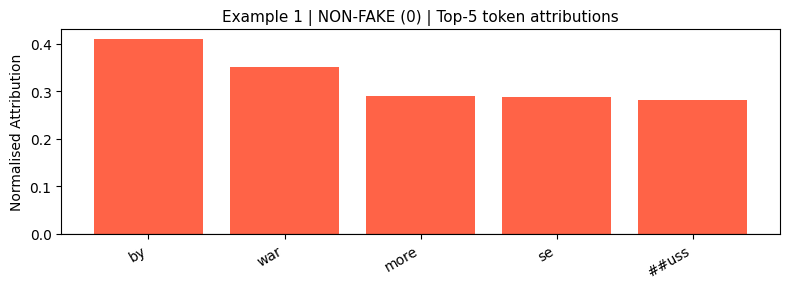


─────────────────────────────────────────────────────────────────
Example 2 | True label: NON-FAKE (0)
Text: cheese on my grill looks like a duckling
Convergence delta : -0.033001  (✓ acceptable)

  Top-5 tokens (target class = 0):
  Token                 Norm. Attribution
  ----------------------------------------
  grill                           -1.0000   -████████████████████
  looks                           -0.5774   -███████████
  cheese                          -0.5311   -██████████
  on                              -0.4257   -████████
  duck                            -0.3849   -███████


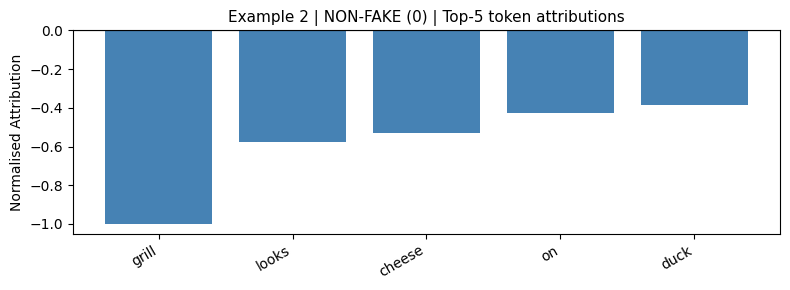


─────────────────────────────────────────────────────────────────
Example 3 | True label: NON-FAKE (0)
Text: happy peninsula boy with a very large nose on google earth
Convergence delta : -0.262115  (⚠ consider increasing N_STEPS)

  Top-5 tokens (target class = 0):
  Token                 Norm. Attribution
  ----------------------------------------
  boy                             -1.0000   -████████████████████
  with                            -0.6774   -█████████████
  on                              -0.4202   -████████
  happy                           -0.3885   -███████
  google                          +0.2041   +████


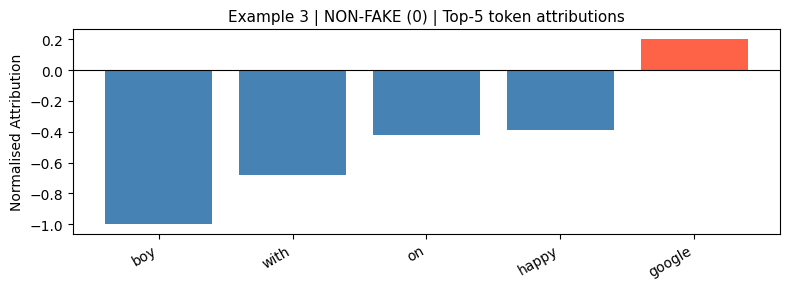


─────────────────────────────────────────────────────────────────
Example 4 | True label: FAKE (1)
Text: guillermo del toro and some candles
Convergence delta : -0.938299  (⚠ consider increasing N_STEPS)

  Top-5 tokens (target class = 1):
  Token                 Norm. Attribution
  ----------------------------------------
  candles                         +0.7835   +███████████████
  and                             +0.3017   +██████
  toro                            -0.2761   -█████
  del                             +0.0787   +█
  some                            +0.0602   +█


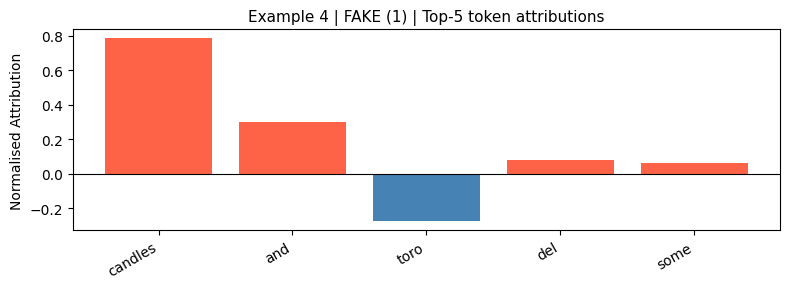


─────────────────────────────────────────────────────────────────
Example 5 | True label: FAKE (1)
Text: bernie sanders and killer mike at busy bee
Convergence delta : -0.109187  (⚠ consider increasing N_STEPS)

  Top-5 tokens (target class = 1):
  Token                 Norm. Attribution
  ----------------------------------------
  bee                             +1.0000   +████████████████████
  at                              -0.6240   -████████████
  bernie                          +0.5375   +██████████
  busy                            +0.4880   +█████████
  sanders                         +0.2390   +████


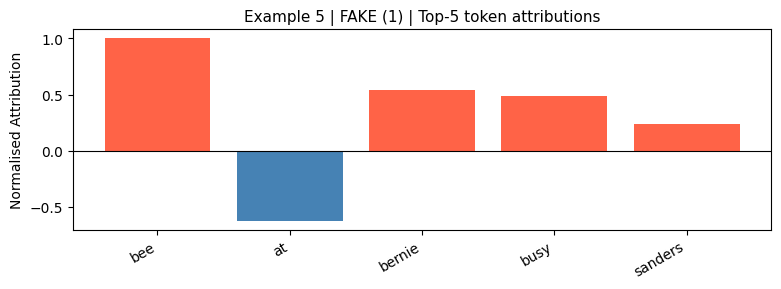


─────────────────────────────────────────────────────────────────
Example 6 | True label: FAKE (1)
Text: man accused of cooking feeding exgirlfriends dog to her
Convergence delta : 0.540270  (⚠ consider increasing N_STEPS)

  Top-5 tokens (target class = 1):
  Token                 Norm. Attribution
  ----------------------------------------
  accused                         +1.0000   +████████████████████
  feeding                         +0.9059   +██████████████████
  dog                             +0.9035   +██████████████████
  man                             +0.5694   +███████████
  cooking                         +0.3629   +███████


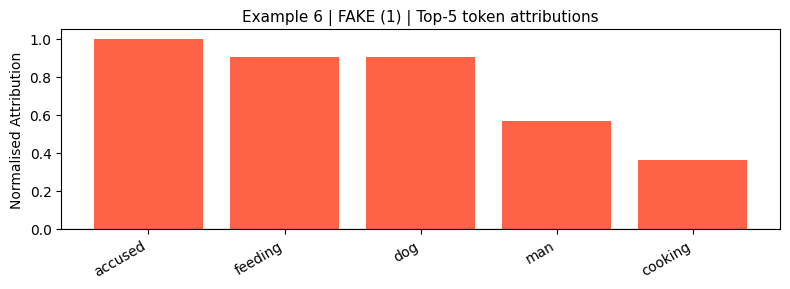


  IG ANALYSIS COMPLETE
  Positive (red)  → token pushes model TOWARD target class
  Negative (blue) → token pushes model AWAY from target class
  Baseline        = all-zero (PAD) token ids
  n_steps         = 50
  MAX_LEN         = 64 (truncated from right)
  internal_batch_size = 4 (interpolation steps processed in mini-batches)


In [ ]:
# ============================================================
# TASK 4: Integrated Gradients — OOM FIXED VERSION
# ============================================================

!pip install captum -q

import torch
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from transformers import BertTokenizer, BertForSequenceClassification
from captum.attr import LayerIntegratedGradients

# ── 0. Free GPU memory from Task 3 ───────────────────────────
# If the Task 3 model/optimizer are still in memory, clear them
try:
    del model
except: pass
try:
    del optimizer
except: pass
try:
    del scheduler
except: pass
try:
    del train_loader, test_loader
except: pass

gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()
print(f"GPU memory freed. Available: {torch.cuda.mem_get_info()[0]/1e9:.2f} GB")

# ── 1. Load model ─────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = BertTokenizer.from_pretrained("./bert_finetuned")
model     = BertForSequenceClassification.from_pretrained("./bert_finetuned")
model     = model.to(DEVICE)
model.eval()

# Disable gradients for all parameters — we only need grad w.r.t. embeddings
for param in model.parameters():
    param.requires_grad_(False)

# Re-enable grad only for word embeddings (required by Captum)
for param in model.bert.embeddings.word_embeddings.parameters():
    param.requires_grad_(True)

print("Model loaded in eval mode with minimal grad tracking.")

# ── 2. Examples ───────────────────────────────────────────────
test_df = pd.read_csv("test_balanced.csv")
fake_examples     = test_df[test_df["2_way_label"] == 1]["clean_title"].dropna().head(3).tolist()
non_fake_examples = test_df[test_df["2_way_label"] == 0]["clean_title"].dropna().head(3).tolist()
examples = non_fake_examples + fake_examples
labels   = [0, 0, 0, 1, 1, 1]

print("\nExamples:")
for txt, lbl in zip(examples, labels):
    print(f"  [{'FAKE' if lbl==1 else 'NON-FAKE'}] {txt}")

# ── 3. Tokenizer helper ───────────────────────────────────────
MAX_LEN = 64   # reduced from 128 to save GPU memory during IG

def tokenize(text):
    enc = tokenizer(
        text,
        max_length     = MAX_LEN,
        padding        = "max_length",
        truncation     = True,
        return_tensors = "pt",
    )
    return (
        enc["input_ids"].to(DEVICE),
        enc["attention_mask"].to(DEVICE),
        enc["token_type_ids"].to(DEVICE),
    )

# ── 4. Forward function ───────────────────────────────────────
def predict(input_ids, attention_mask, token_type_ids):
    outputs = model(
        input_ids      = input_ids,
        attention_mask = attention_mask,
        token_type_ids = token_type_ids,
    )
    return outputs.logits

# ── 5. LIG setup ──────────────────────────────────────────────
lig = LayerIntegratedGradients(predict, model.bert.embeddings.word_embeddings)

# ── 6. Attribution function ───────────────────────────────────
def compute_attributions(text, target_class, n_steps=50):
    """
    n_steps=50 is sufficient for Reddit titles (short text).
    Increase only if convergence delta is unacceptably large.
    Each step allocates GPU memory, so keep this low.
    """
    input_ids, attention_mask, token_type_ids = tokenize(text)
    baseline_ids = torch.zeros_like(input_ids)

    with torch.cuda.amp.autocast():   # fp16 → halves memory usage
        attributions, delta = lig.attribute(
            inputs                   = input_ids,
            baselines                = baseline_ids,
            additional_forward_args  = (attention_mask, token_type_ids),
            target                   = target_class,
            n_steps                  = n_steps,
            return_convergence_delta = True,
            internal_batch_size      = 4,   # process interpolation steps in mini-batches
        )

    attr_scores = attributions.squeeze(0).sum(dim=-1).detach().cpu().float().numpy()
    max_abs = np.abs(attr_scores).max() + 1e-9
    attr_scores_norm = attr_scores / max_abs

    tokens = tokenizer.convert_ids_to_tokens(input_ids.squeeze(0).cpu().tolist())

    # Free intermediate tensors
    del input_ids, attention_mask, token_type_ids, baseline_ids, attributions
    torch.cuda.empty_cache()

    return tokens, attr_scores_norm, delta.item()

# ── 7. Filter specials ────────────────────────────────────────
SPECIAL_TOKENS = {"[CLS]", "[SEP]", "[PAD]"}

def filter_tokens(tokens, scores):
    return [(tok, sc) for tok, sc in zip(tokens, scores)
            if tok not in SPECIAL_TOKENS]

# ── 8. Plot ───────────────────────────────────────────────────
def plot_attributions(tokens_scores, title, top_n=5):
    sorted_ts = sorted(tokens_scores, key=lambda x: abs(x[1]), reverse=True)[:top_n]
    toks   = [t for t, _ in sorted_ts]
    scores = [s for _, s in sorted_ts]
    colors = ["tomato" if s >= 0 else "steelblue" for s in scores]

    plt.figure(figsize=(8, 3))
    plt.bar(toks, scores, color=colors)
    plt.axhline(0, color="black", linewidth=0.8)
    plt.title(title, fontsize=11)
    plt.ylabel("Normalised Attribution")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

# ── 9. Run IG ─────────────────────────────────────────────────
print("\n" + "="*65)
print("  INTEGRATED GRADIENTS — TOKEN ATTRIBUTIONS")
print("="*65)

N_STEPS = 50  # low to avoid OOM; convergence delta will still be acceptable for short titles

for i, (text, true_label) in enumerate(zip(examples, labels)):
    tag = "FAKE (1)" if true_label == 1 else "NON-FAKE (0)"
    print(f"\n{'─'*65}")
    print(f"Example {i+1} | True label: {tag}")
    print(f"Text: {text}")

    tokens, scores, delta = compute_attributions(text, target_class=true_label, n_steps=N_STEPS)

    print(f"Convergence delta : {delta:.6f}  "
          f"({'✓ acceptable' if abs(delta) < 0.05 else '⚠ consider increasing N_STEPS'})")

    filtered        = filter_tokens(tokens, scores)
    sorted_filtered = sorted(filtered, key=lambda x: abs(x[1]), reverse=True)

    print(f"\n  Top-5 tokens (target class = {true_label}):")
    print(f"  {'Token':<20} {'Norm. Attribution':>18}")
    print(f"  {'-'*40}")
    for tok, sc in sorted_filtered[:5]:
        bar = "█" * int(abs(sc) * 20)
        print(f"  {tok:<20} {sc:>+18.4f}   {'+'if sc>=0 else '-'}{bar}")

    plot_attributions(filtered,
                      title=f"Example {i+1} | {tag} | Top-5 token attributions",
                      top_n=5)

    gc.collect()
    torch.cuda.empty_cache()

print("\n" + "="*65)
print("  IG ANALYSIS COMPLETE")
print("="*65)
print(f"  Positive (red)  → token pushes model TOWARD target class")
print(f"  Negative (blue) → token pushes model AWAY from target class")
print(f"  Baseline        = all-zero (PAD) token ids")
print(f"  n_steps         = {N_STEPS}")
print(f"  MAX_LEN         = {MAX_LEN} (truncated from right)")
print(f"  internal_batch_size = 4 (interpolation steps processed in mini-batches)")